In [9]:
%matplotlib inline
# Importing standard Qiskit libraries
from qiskit import QuantumCircuit, execute, Aer, IBMQ, QuantumRegister, ClassicalRegister
from qiskit.compiler import transpile, assemble
from qiskit.tools.jupyter import *
from qiskit.visualization import *
from ibm_quantum_widgets import *

# Loading your IBM Q account(s)
provider = IBMQ.load_account()

import numpy as np
from math import pi

ibmqfactory.load_account:WARNING:2021-03-02 12:02:57,855: Credentials are already in use. The existing account in the session will be replaced.


In [10]:
QN=4;Layer=3;Shots=8000;
N_ph=20;phi0=np.empty([2,1]);theta=pi/1.5;
phi=np.empty([N_ph,1]);
outcome=np.empty([2,N_ph]);
phi0[0][0]=pi/1.5
phi0[1][0]=pi/4
d_ph=2*pi/(N_ph-1);
for i in range(0,N_ph):
    phi[i][0]=-pi+i*d_ph
my_provider=IBMQ.get_provider(hub='ibm-q-research',group='nankai-1',project='main')
backend = my_provider.get_backend('ibmq_rome')

In [11]:
for i_ph0 in range(0,2):
    for i_ph in range(0,N_ph):
        circuit=QuantumCircuit(QN,QN)
        qreg_q = QuantumRegister(QN, 'q')
        creg_c = ClassicalRegister(QN, 'c')
        for i in range(0,QN):
            circuit.reset(i)
        circuit.x(0)
        for j in range(0,Layer):
            for i in range(0,QN-1):
                circuit.rz(pi/2,i)
                circuit.h(i+1)
                circuit.cx(i+1,i)
                circuit.rz(-pi/2,i)
                circuit.rz(pi/2,i+1)
                circuit.h(i)
                circuit.h(i+1)
                circuit.rz(theta/2,i)
                circuit.rz(-theta/2,i+1)
                circuit.rz(pi/2,i)
                circuit.h(i+1)
                circuit.cx(i+1,i)
                circuit.rz(-pi/2,i)
                circuit.rz(pi/2,i+1)
                circuit.h(i)
                circuit.h(i+1)
                if j<Layer-1:
                    if i==QN-2:
                        circuit.rz(phi[i_ph][0],0)
                        circuit.rz(phi0[i_ph0][0],1)
                        circuit.rz(-phi0[i_ph0][0],2)
                        circuit.rz(phi[i_ph][0],3)
        circuit.measure(qreg_q[3], creg_c[3]);
        job = execute(circuit, backend=backend, shots=Shots)
        counts=job.result().get_counts().get('1000')
        if counts is None:
            outcome[i_ph0][i_ph]=0
        else:
            outcome[i_ph0][i_ph]=counts/Shots

In [12]:
print(outcome)

[[0.19325  0.212625 0.2425   0.292625 0.325    0.341125 0.331875 0.295125
  0.267125 0.269625 0.275625 0.29525  0.351125 0.37325  0.387    0.36075
  0.3225   0.2775   0.225875 0.203625]
 [0.301875 0.314    0.3195   0.332875 0.333875 0.31475  0.288375 0.23875
  0.20725  0.18525  0.203375 0.226875 0.2655   0.317625 0.3405   0.351625
  0.34225  0.32025  0.30975  0.293625]]


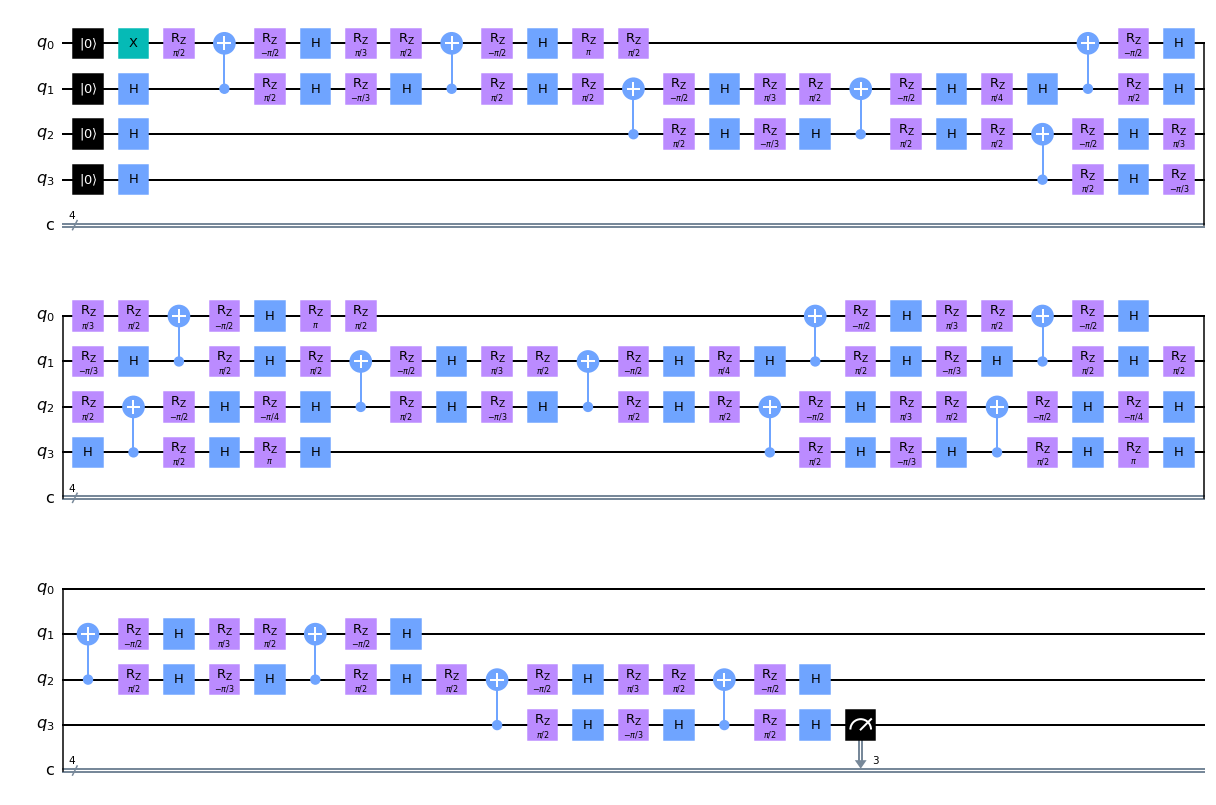

In [13]:
circuit.draw()